<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch06_Dimensionality_Reduction_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Dimensionality Reduction -- Squashing the Data Pancake with PCA

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

With automatic data collection and feature generation, one can quickly accumulate hundreds or thousands of features. But not all are useful -- many are redundant, carrying information already captured by other features. **Principal Component Analysis (PCA)** is the most widely used technique for reducing feature dimensionality while retaining as much information as possible.

This chapter marks an entry into **model-based feature engineering**. Prior techniques (frequency filtering, tf-idf) could be defined without looking at the data. PCA, by contrast, requires computing the principal axes *from* the data itself. The line between features and models starts to blur.

This chapter covers:

1. **Intuition** -- what PCA does geometrically (squashing the data pancake)
2. **Derivation** -- from variance maximization to SVD
3. **Implementation** -- PCA on the MNIST digits dataset
4. **Whitening and ZCA** -- decorrelating and normalizing features
5. **Considerations** -- when PCA helps and when it hurts

## Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")

Environment ready.
NumPy: 2.0.2
scikit-learn: 1.6.1


This chapter uses only scikit-learn's built-in digits dataset -- no external downloads needed. All code runs locally or on Colab without any data files.

## 6.1 Intuition

Dimensionality reduction is about getting rid of "uninformative information" while retaining the crucial bits. PCA focuses on **linear dependency**: if some features are linear combinations of others, they are redundant and can be compressed.

Picture a blob of data points in feature space:

- **Full rank (Figure 6-1a):** The blob fills the space -- both features carry independent information
- **Low rank (Figure 6-1b):** The blob is flat because feature 1 is a copy (or scalar multiple) of feature 2. Intrinsic dimensionality = 1
- **Approximately low rank (Figure 6-1c):** The blob is thin but not perfectly flat. We can squash it with minimal information loss

PCA finds the directions of maximum variance ("the widest directions of the pancake") and projects the data onto those directions.

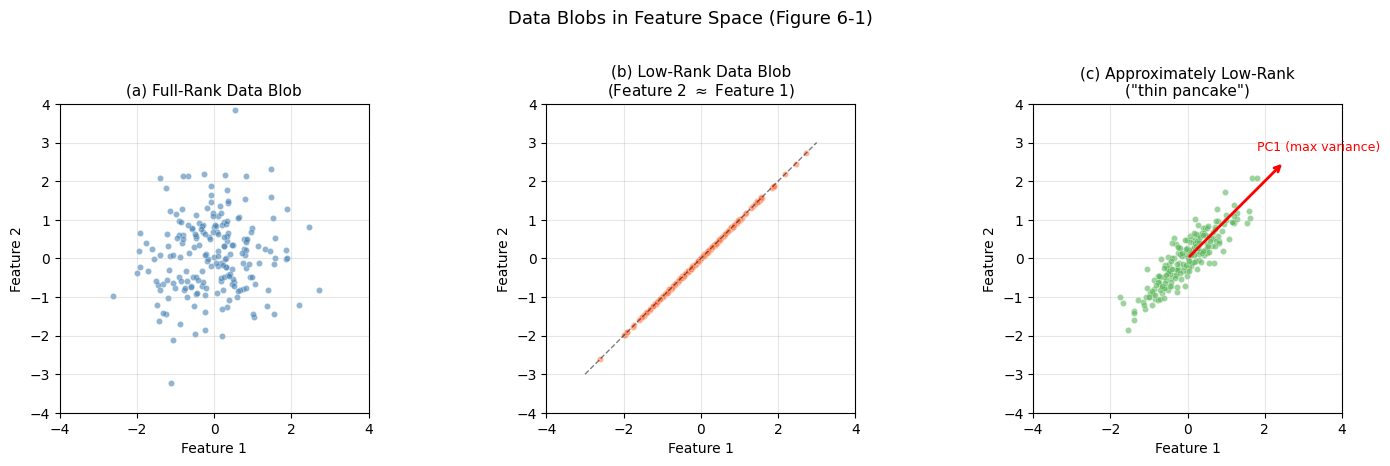

In [ ]:
# Figure 6-1: Data blobs -- full rank, low rank, approximately low rank
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Full-rank blob
x1 = np.random.randn(200)
x2 = np.random.randn(200)
axes[0].scatter(x1, x2, s=20, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
axes[0].set_title('(a) Full-Rank Data Blob', fontsize=11)
axes[0].set_xlabel('Feature 1', fontsize=10)
axes[0].set_ylabel('Feature 2', fontsize=10)
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

# (b) Low-rank blob (feature 2 = feature 1)
x2_low = x1 + np.random.randn(200) * 0.01
axes[1].scatter(x1, x2_low, s=20, alpha=0.6, color='coral', edgecolors='white', linewidths=0.3)
axes[1].plot([-3, 3], [-3, 3], 'k--', alpha=0.5, linewidth=1)
axes[1].set_title('(b) Low-Rank Data Blob\n(Feature 2 $\\approx$ Feature 1)', fontsize=11)
axes[1].set_xlabel('Feature 1', fontsize=10)
axes[1].set_ylabel('Feature 2', fontsize=10)
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

# (c) Approximately low-rank (thin pancake)
angle = np.pi / 4
x_rot = x1 * np.cos(angle) - np.random.randn(200) * 0.3 * np.sin(angle)
y_rot = x1 * np.sin(angle) + np.random.randn(200) * 0.3 * np.cos(angle)
axes[2].scatter(x_rot, y_rot, s=20, alpha=0.6, color='#5CB85C', edgecolors='white', linewidths=0.3)
axes[2].annotate('', xy=(2.5, 2.5), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[2].text(1.8, 2.8, 'PC1 (max variance)', fontsize=9, color='red')
axes[2].set_title('(c) Approximately Low-Rank\n("thin pancake")', fontsize=11)
axes[2].set_xlabel('Feature 1', fontsize=10)
axes[2].set_ylabel('Feature 2', fontsize=10)
axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

fig.suptitle('Data Blobs in Feature Space (Figure 6-1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Panel (a):** The data fills the 2D space uniformly. Both features carry independent information -- reducing to 1D would lose roughly half the variance. PCA would not help much here.

**Panel (b):** Feature 2 is essentially a copy of Feature 1 (plus tiny noise). The blob collapses onto a 1D line. The intrinsic dimensionality is 1 despite living in a 2D space. PCA trivially identifies this and reduces to 1D with nearly zero loss.

**Panel (c):** The "thin pancake" -- the real-world scenario. The data has a dominant direction of variance (the red arrow, PC1) and a much smaller secondary direction. Projecting onto PC1 alone captures most of the variance, reducing 2D to 1D with minimal loss. This is what PCA does: **find the widest directions of the pancake and keep only those**.

Mathematically, "widest direction" means **maximum variance**. PCA finds the direction $\mathbf{v}$ that maximizes the variance of the projected data:

$$\max_{\mathbf{v}} \text{Var}(\mathbf{X}\mathbf{v}) \quad \text{subject to} \quad \|\mathbf{v}\|_2 = 1$$

## 6.2 Mathematical Derivation

### Step 1: Center the Data

Subtract the mean from each feature so the data has zero mean:

$$\mathbf{C} = \mathbf{X} - \mathbf{1}\boldsymbol{\mu}^T$$

where $\mathbf{1}$ is a column of ones and $\boldsymbol{\mu}$ is the column vector of feature means. Centering ensures that variance equals the expectation of the squared values: $\text{Var}(Z) = \mathbb{E}[Z^2]$ when $\mathbb{E}[Z] = 0$.

### Step 2: Projection

Project each data point $\mathbf{x}$ onto a direction $\mathbf{v}$:

$$z = \mathbf{x}^T \mathbf{v}$$

The scalar $z$ is the **projection coordinate** -- the "shadow" of $\mathbf{x}$ on $\mathbf{v}$. For all data points at once:

$$\mathbf{z} = \mathbf{X}\mathbf{v}$$

### Step 3: Maximize Variance

The empirical variance of the projections is:

$$\text{Var}_{\text{emp}}(\mathbf{z}) = \frac{1}{n-1}\sum_{i=1}^{n} z_i^2 = \frac{1}{n-1}\|\mathbf{X}\mathbf{v}\|^2 = \frac{1}{n-1}\mathbf{v}^T\mathbf{X}^T\mathbf{X}\mathbf{v}$$

Maximizing this subject to $\|\mathbf{v}\| = 1$ is an eigenvalue problem. The solution: $\mathbf{v}$ is the **eigenvector of $\mathbf{X}^T\mathbf{X}$ with the largest eigenvalue** -- equivalently, the right singular vector of $\mathbf{X}$ with the largest singular value.

### Step 4: SVD Connection

The **Singular Value Decomposition (SVD)** of the centered data matrix is:

$$\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$$

where $\mathbf{U}$ ($n \times d$) and $\mathbf{V}$ ($d \times d$) are orthogonal matrices, and $\boldsymbol{\Sigma}$ ($d \times d$) is diagonal with singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_d \geq 0$.

The **principal components** are the columns of $\mathbf{V}$ (right singular vectors). The **transformed data** is:

$$\mathbf{Z} = \mathbf{X}\mathbf{V}_k = \mathbf{U}_k\boldsymbol{\Sigma}_k$$

where the subscript $k$ denotes keeping only the first $k$ components.

=== PCA Step by Step ===
Data shape: (300, 2)
Mean (before centering): [-0.0055, -0.0152]
Mean (after centering):  [2.5e-17, -2.7e-17]

Singular values: [22.2377, 6.3574]
Variance explained: [0.9244, 0.0756]

Principal component 1: [-0.7408, -0.6717]
Principal component 2: [-0.6717, 0.7408]

PC1 dot PC2 = 0.0e+00 (orthogonal)


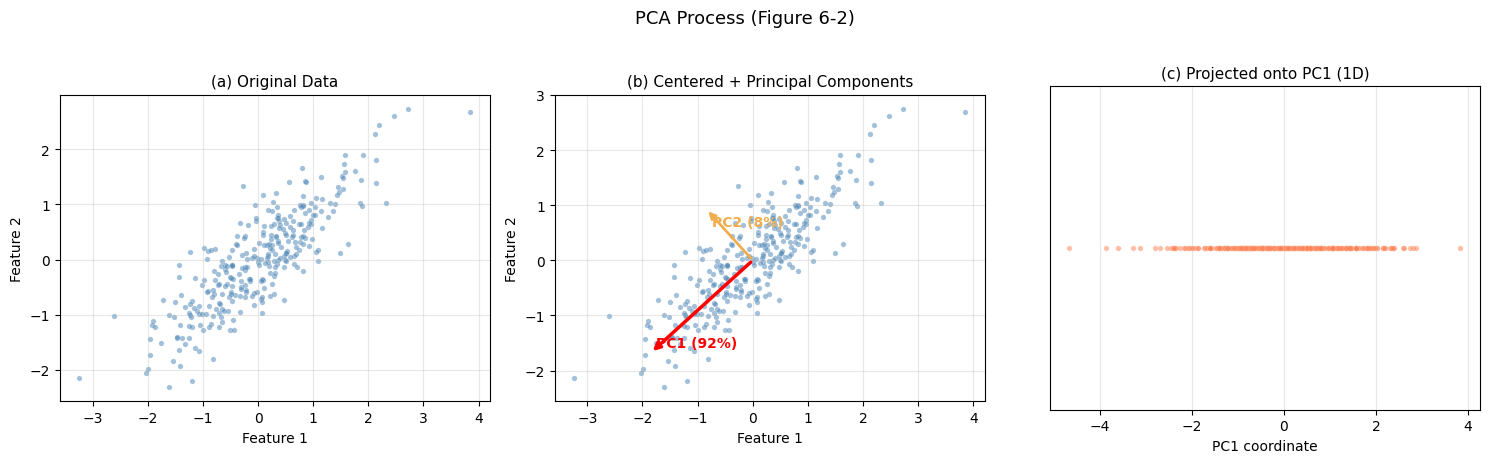

In [ ]:
# Demonstrate PCA step by step on a 2D example
np.random.seed(42)

# Generate correlated 2D data
n = 300
x1 = np.random.randn(n)
x2 = 0.8 * x1 + 0.5 * np.random.randn(n)
X = np.column_stack([x1, x2])

# Step 1: Center
X_centered = X - X.mean(axis=0)

# Step 2: SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
V = Vt.T  # columns are principal components

print("=== PCA Step by Step ===")
print(f"Data shape: {X.shape}")
print(f"Mean (before centering): [{X.mean(axis=0)[0]:.4f}, {X.mean(axis=0)[1]:.4f}]")
print(f"Mean (after centering):  [{X_centered.mean(axis=0)[0]:.1e}, {X_centered.mean(axis=0)[1]:.1e}]")
print(f"\nSingular values: [{S[0]:.4f}, {S[1]:.4f}]")
print(f"Variance explained: [{S[0]**2/(S**2).sum():.4f}, {S[1]**2/(S**2).sum():.4f}]")
print(f"\nPrincipal component 1: [{V[0,0]:.4f}, {V[1,0]:.4f}]")
print(f"Principal component 2: [{V[0,1]:.4f}, {V[1,1]:.4f}]")
print(f"\nPC1 dot PC2 = {V[:,0] @ V[:,1]:.1e} (orthogonal)")

# Figure 6-2: PCA process visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Original data
axes[0].scatter(X[:,0], X[:,1], s=15, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.2)
axes[0].set_title('(a) Original Data', fontsize=11)
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

# (b) Centered data with principal components
axes[1].scatter(X_centered[:,0], X_centered[:,1], s=15, alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.2)
scale = 2.5
axes[1].annotate('', xy=(V[0,0]*scale, V[1,0]*scale), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
axes[1].annotate('', xy=(V[0,1]*scale*0.5, V[1,1]*scale*0.5), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#F0AD4E', lw=2))
axes[1].text(V[0,0]*scale+0.1, V[1,0]*scale+0.1, f'PC1 ({S[0]**2/(S**2).sum():.0%})', color='red', fontsize=10, fontweight='bold')
axes[1].text(V[0,1]*scale*0.5+0.1, V[1,1]*scale*0.5-0.3, f'PC2 ({S[1]**2/(S**2).sum():.0%})', color='#F0AD4E', fontsize=10, fontweight='bold')
axes[1].set_title('(b) Centered + Principal Components', fontsize=11)
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

# (c) Projected onto PC1 (1D)
Z = X_centered @ V[:, :1]
axes[2].scatter(Z[:, 0], np.zeros(n), s=15, alpha=0.5, color='coral', edgecolors='white', linewidths=0.2)
axes[2].set_title('(c) Projected onto PC1 (1D)', fontsize=11)
axes[2].set_xlabel('PC1 coordinate'); axes[2].set_ylabel('')
axes[2].set_yticks([])
axes[2].grid(True, alpha=0.3, axis='x')

fig.suptitle('PCA Process (Figure 6-2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The three panels illustrate the PCA process:

**(a) Original data:** Two correlated features. The data blob is elongated along the direction where $x_2 \approx 0.8 x_1$.

**(b) Centered data with PCs:** After centering (subtracting the mean), the two principal components are shown as arrows. **PC1** (red) aligns with the direction of maximum variance -- the "long axis" of the pancake. **PC2** (orange) is orthogonal and captures the remaining, smaller variance. The percentages show how much of the total variance each component explains.

**(c) Projected onto PC1:** Projecting the 2D data onto PC1 alone reduces it to 1D. Each point is now described by a single number (its coordinate along PC1) instead of two. The variance along this axis captures most of the total information.

The singular values $\sigma_1$ and $\sigma_2$ directly measure the "width" of the pancake in each direction. The ratio $\sigma_1^2 / (\sigma_1^2 + \sigma_2^2)$ gives the fraction of variance explained by PC1.

## 6.3 PCA in Action: MNIST Digits

The MNIST dataset contains images of handwritten digits (0--9). The scikit-learn subset has $1{,}797$ images, each $8 \times 8$ pixels = 64 features. We apply PCA and visualize the data using the first few principal components.

=== MNIST Digits Dataset ===
Number of images: 1797
Image shape:      (8, 8) -> flattened to 64 features
Labels:           [0 1 2 3 4 5 6 7 8 9]


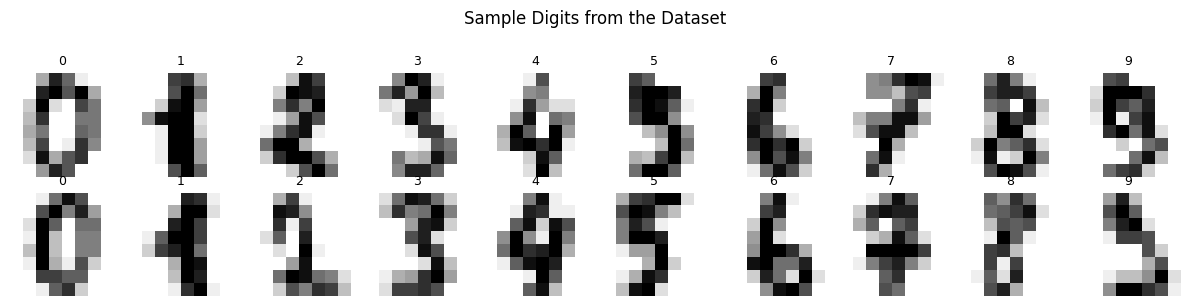

In [ ]:
# Example 6-1: PCA on scikit-learn digits dataset
from sklearn import datasets
from sklearn.decomposition import PCA

# Load data
digits_data = datasets.load_digits()
n = len(digits_data.images)
image_data = digits_data.images.reshape((n, -1))
labels = digits_data.target

print(f"=== MNIST Digits Dataset ===")
print(f"Number of images: {n}")
print(f"Image shape:      {digits_data.images[0].shape} -> flattened to {image_data.shape[1]} features")
print(f"Labels:           {np.unique(labels)}")

# Show some sample digits
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(digits_data.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(str(labels[i]), fontsize=9)
    ax.axis('off')
fig.suptitle('Sample Digits from the Dataset', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Each image is an $8 \times 8$ grayscale grid, flattened into a 64-dimensional feature vector. The pixel intensities range from 0 (white) to 16 (black). With 64 features, the data lives in a 64-dimensional space -- far too many dimensions to visualize directly. PCA will help us reduce this to 2 or 3 dimensions while retaining as much structure as possible.

In [ ]:
# Fit PCA to retain 80% of variance
pca_80 = PCA(n_components=0.8)
pca_images_80 = pca_80.fit_transform(image_data)

print(f"=== PCA: Retaining 80% of Variance ===")
print(f"Original features:   {image_data.shape[1]}")
print(f"PCA components:      {pca_80.n_components_}")
print(f"Compression ratio:   {image_data.shape[1] / pca_80.n_components_:.1f}x")
print(f"\nExplained variance ratios (first 13 components):")
for i, var in enumerate(pca_80.explained_variance_ratio_):
    bar = '#' * int(var * 100)
    print(f"  PC{i+1:2d}: {var:.4f} ({var*100:5.1f}%) {bar}")
print(f"\n  Total: {pca_80.explained_variance_ratio_.sum():.4f}")

# First 3 components
print(f"\nFirst 3 components explain: {pca_80.explained_variance_ratio_[:3].sum():.4f} "
      f"({pca_80.explained_variance_ratio_[:3].sum()*100:.1f}%)")

=== PCA: Retaining 80% of Variance ===
Original features:   64
PCA components:      13
Compression ratio:   4.9x

Explained variance ratios (first 13 components):
  PC 1: 0.1489 ( 14.9%) ##############
  PC 2: 0.1362 ( 13.6%) #############
  PC 3: 0.1179 ( 11.8%) ###########
  PC 4: 0.0841 (  8.4%) ########
  PC 5: 0.0578 (  5.8%) #####
  PC 6: 0.0492 (  4.9%) ####
  PC 7: 0.0432 (  4.3%) ####
  PC 8: 0.0366 (  3.7%) ###
  PC 9: 0.0335 (  3.4%) ###
  PC10: 0.0308 (  3.1%) ###
  PC11: 0.0237 (  2.4%) ##
  PC12: 0.0227 (  2.3%) ##
  PC13: 0.0182 (  1.8%) #

  Total: 0.8029

First 3 components explain: 0.4030 (40.3%)


To retain 80% of the total variance, PCA selects **13 components** out of the original 64 features -- a $4.9\times$ compression. The first component alone captures about $14.9\%$ of the variance, the second about $13.6\%$, and the third about $11.8\%$.

Notice the diminishing returns: the first 3 components explain $\sim 40\%$ of variance; we need 10 more to reach 80%. This is typical -- a few components capture the dominant structure, but the remaining variance is spread across many smaller components.

The threshold of 80% is a common heuristic. The textbook formulation:

$$\text{Pick } k \text{ such that } \frac{\sum_{i=1}^{k} \sigma_i^2}{\sum_{i=1}^{d} \sigma_i^2} \geq 0.8$$

where $\sigma_i$ are the singular values of the centered data matrix.

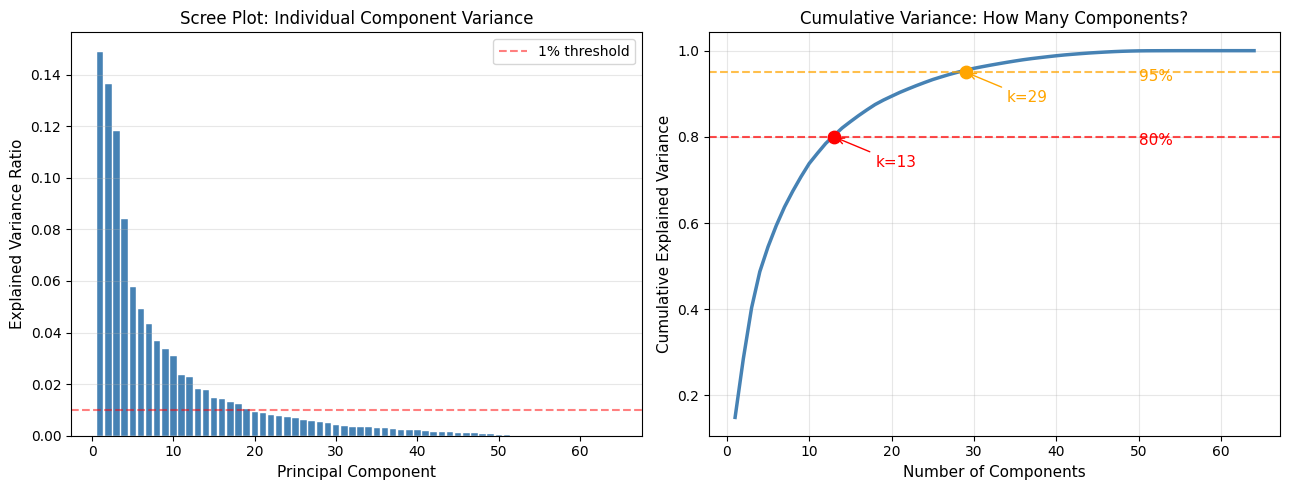

Components for 80% variance: 13 (out of 64)
Components for 95% variance: 29 (out of 64)


In [ ]:
# Scree plot (spectrum analysis)
pca_full = PCA().fit(image_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, color='steelblue',
        edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance Ratio', fontsize=11)
ax1.set_title('Scree Plot: Individual Component Variance', fontsize=12)
ax1.axhline(0.01, color='red', linestyle='--', alpha=0.5, label='1% threshold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Cumulative variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(range(1, len(cumvar) + 1), cumvar, 'steelblue', linewidth=2.5)
ax2.axhline(0.8, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.axhline(0.95, color='orange', linestyle='--', alpha=0.7, linewidth=1.5)
ax2.text(50, 0.78, '80%', color='red', fontsize=11)
ax2.text(50, 0.93, '95%', color='orange', fontsize=11)

# Mark the 80% and 95% crossing points
k80 = np.argmax(cumvar >= 0.8) + 1
k95 = np.argmax(cumvar >= 0.95) + 1
ax2.scatter([k80], [0.8], s=80, color='red', zorder=5)
ax2.scatter([k95], [0.95], s=80, color='orange', zorder=5)
ax2.annotate(f'k={k80}', xy=(k80, 0.8), xytext=(k80+5, 0.73),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
ax2.annotate(f'k={k95}', xy=(k95, 0.95), xytext=(k95+5, 0.88),
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=11, color='orange')

ax2.set_xlabel('Number of Components', fontsize=11)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax2.set_title('Cumulative Variance: How Many Components?', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Components for 80% variance: {k80} (out of {image_data.shape[1]})")
print(f"Components for 95% variance: {k95} (out of {image_data.shape[1]})")

**Left (Scree Plot):** The individual variance per component drops sharply after the first few PCs, then levels off into a long tail of small contributions. Components below the 1% threshold (red dashed) contribute very little individually.

**Right (Cumulative Variance):** The cumulative curve shows how many components are needed to reach a target variance threshold. 13 components reach 80%; roughly 30 reach 95%. This curve is the primary tool for choosing $k$ -- pick the "elbow" where adding more components gives diminishing returns.

The **spectrum** (ordered singular values) encodes the intrinsic dimensionality of the data. A sharp drop-off means the data is effectively low-dimensional; a gradual decline means information is spread across many dimensions and compression will be lossy.

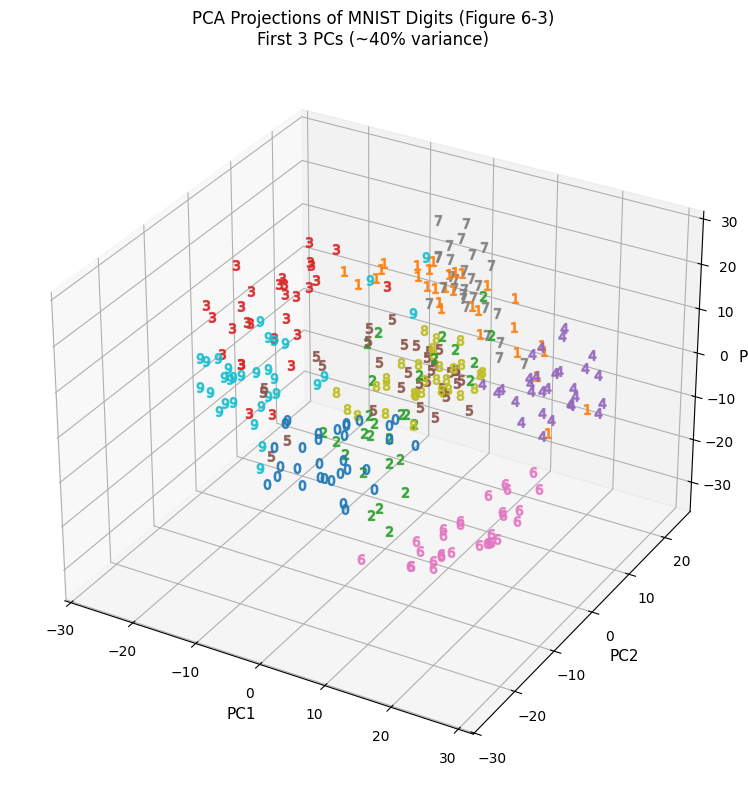

Observations:
- 0 and 6 cluster together (round shapes)
- 1 and 7 cluster together (vertical strokes)
- 3 and 9 overlap (similar curves)
- The space roughly separates round digits from angular ones


In [ ]:
# Figure 6-3: 3D PCA visualization with digit labels
pca_3d = PCA(n_components=3)
pca_3d_data = pca_3d.fit_transform(image_data)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot first 300 points with digit markers
colors_map = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(300):
    ax.scatter(pca_3d_data[i, 0], pca_3d_data[i, 1], pca_3d_data[i, 2],
               marker=f'${labels[i]}$', s=50, color=colors_map[labels[i]], alpha=0.8)

ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_zlabel('PC3', fontsize=11)
ax.set_title('PCA Projections of MNIST Digits (Figure 6-3)\nFirst 3 PCs (~40% variance)',
             fontsize=12)
plt.tight_layout()
plt.show()

print("Observations:")
print("- 0 and 6 cluster together (round shapes)")
print("- 1 and 7 cluster together (vertical strokes)")
print("- 3 and 9 overlap (similar curves)")
print("- The space roughly separates round digits from angular ones")

The 3D visualization shows the first 300 digit images projected onto their first three principal components (accounting for $\sim 40\%$ of total variance). Despite capturing less than half the information, PCA already reveals structure:

- **0 and 6** cluster together -- both have round shapes
- **1 and 7** cluster together -- both are essentially vertical strokes
- **3 and 9** overlap -- similar curved structures
- The space roughly divides round digits (0, 6, 8) from angular ones (1, 4, 7)

With only 3 dimensions, there is significant overlap between clusters, so a linear classifier in this space would struggle. But the fact that any structure is visible from a $64 \to 3$ compression ($21\times$ reduction) demonstrates PCA's power.

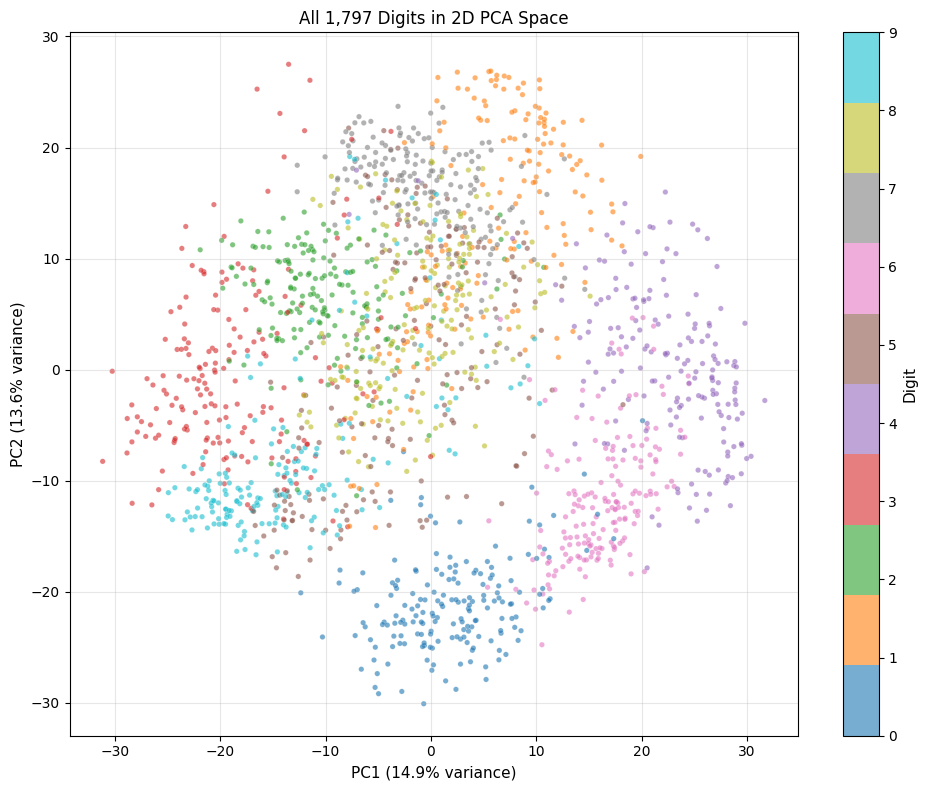

In [ ]:
# 2D projection colored by digit
fig, ax = plt.subplots(figsize=(10, 8))
pca_2d = PCA(n_components=2)
Z_2d = pca_2d.fit_transform(image_data)

scatter = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=labels, cmap='tab10',
                     s=15, alpha=0.6, edgecolors='white', linewidths=0.2)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit', fontsize=11)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('All 1,797 Digits in 2D PCA Space', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The full dataset projected onto 2 PCs shows clear clustering for some digits (0s in orange are well-separated; 1s in blue form a distinct cluster) but heavy overlap for others (3, 5, 8, 9 all mix together in the center). This confirms that 2 dimensions are insufficient for digit classification, but excellent for exploratory visualization.

## 6.4 What Do Principal Components Look Like?

Since each image is an $8 \times 8$ grid flattened to 64 features, each principal component is also a 64-dimensional vector that can be reshaped back into an $8 \times 8$ image. These "eigendigits" reveal the dominant spatial patterns in the data.

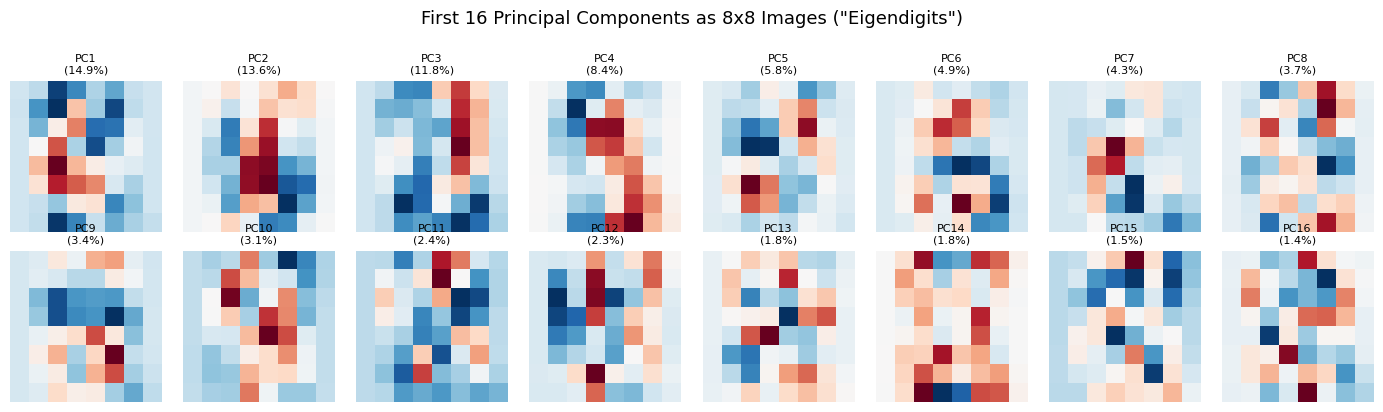

In [ ]:
# Visualize the principal components as images
pca_all = PCA(n_components=16).fit(image_data)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(pca_all.components_[i].reshape(8, 8), cmap='RdBu_r',
              interpolation='nearest')
    var_pct = pca_all.explained_variance_ratio_[i] * 100
    ax.set_title(f'PC{i+1}\n({var_pct:.1f}%)', fontsize=8)
    ax.axis('off')

fig.suptitle('First 16 Principal Components as 8x8 Images ("Eigendigits")', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The principal components ("eigendigits") reveal the dominant spatial patterns:

- **PC1** captures overall brightness/contrast -- the most basic variation across all digits
- **PC2--4** capture major structural patterns: horizontal vs vertical strokes, diagonal orientations
- **Higher PCs** capture increasingly fine-grained details and edge patterns

Each digit image can be approximated as a weighted sum of these components: $\hat{\mathbf{x}} \approx \bar{\mathbf{x}} + z_1\mathbf{v}_1 + z_2\mathbf{v}_2 + \cdots + z_k\mathbf{v}_k$, where $z_i$ are the PC coordinates and $\mathbf{v}_i$ are the component images. More components = better reconstruction.

## 6.5 Whitening and ZCA

Due to orthogonality, PCA-transformed features are **uncorrelated**:

$$\mathbf{Z}^T\mathbf{Z} = \boldsymbol{\Sigma}_k^2$$

a diagonal matrix. The features have zero cross-correlation but different scales (the singular values).

**Whitening** goes one step further: normalize each component to unit variance:

$$\mathbf{Z}_{\text{white}} = \mathbf{X}\mathbf{V}_k\boldsymbol{\Sigma}_k^{-1} = \mathbf{U}_k$$

After whitening, $\mathbf{Z}_{\text{white}}^T\mathbf{Z}_{\text{white}} = \mathbf{I}$ -- the identity matrix. Features are both uncorrelated and unit-scaled.

**ZCA (Zero-phase Component Analysis)** whitens without reducing dimensionality. It uses all components and rotates back to the original feature space:

$$\mathbf{Z}_{\text{ZCA}} = \mathbf{X}\mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{V}^T$$

ZCA produces whitened data that is **as close as possible** (in Euclidean distance) to the original data. It is commonly used as a preprocessing step for image-based deep learning.

=== PCA vs. Whitened PCA ===

Standard PCA - Component variances:
  [178.91 163.63 141.71 101.04  69.47  59.08  51.86  43.99  40.29  36.99]

Whitened PCA - Component variances:
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


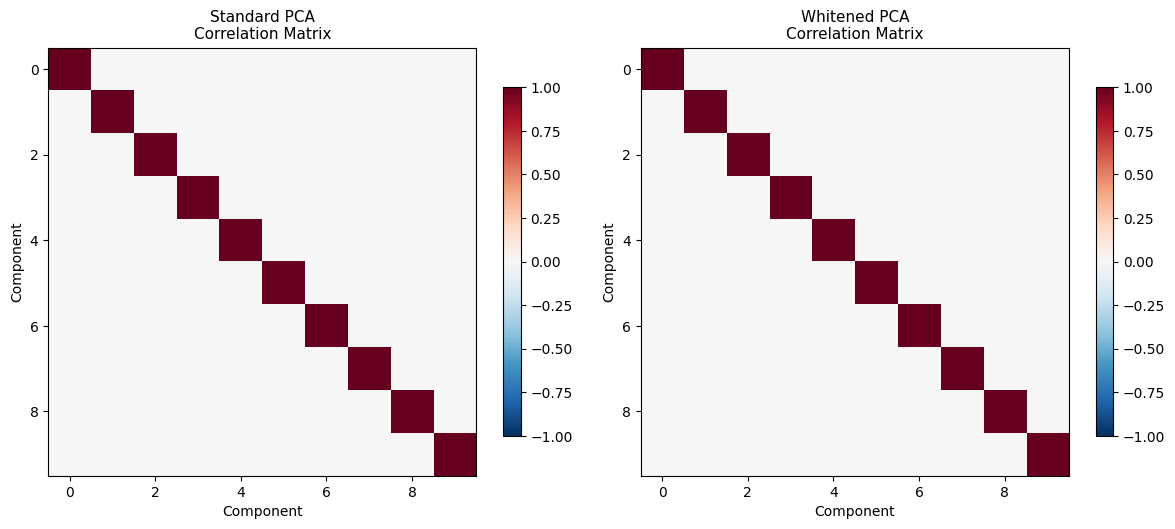


Both produce diagonal correlation matrices (uncorrelated features).
Whitening additionally normalizes all variances to ~1.0.


In [ ]:
# Demonstrate whitening on the digits data
from sklearn.decomposition import PCA

# Standard PCA (no whitening)
pca_std = PCA(n_components=10)
Z_std = pca_std.fit_transform(image_data)

# PCA with whitening
pca_white = PCA(n_components=10, whiten=True)
Z_white = pca_white.fit_transform(image_data)

print("=== PCA vs. Whitened PCA ===")
print(f"\nStandard PCA - Component variances:")
print(f"  {Z_std.var(axis=0).round(2)}")
print(f"\nWhitened PCA - Component variances:")
print(f"  {Z_white.var(axis=0).round(2)}")

# Correlation matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

corr_std = np.corrcoef(Z_std.T)
corr_white = np.corrcoef(Z_white.T)

im1 = ax1.imshow(corr_std, cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_title('Standard PCA\nCorrelation Matrix', fontsize=11)
ax1.set_xlabel('Component'); ax1.set_ylabel('Component')
plt.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(corr_white, cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title('Whitened PCA\nCorrelation Matrix', fontsize=11)
ax2.set_xlabel('Component'); ax2.set_ylabel('Component')
plt.colorbar(im2, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

print("\nBoth produce diagonal correlation matrices (uncorrelated features).")
print("Whitening additionally normalizes all variances to ~1.0.")

Both standard PCA and whitened PCA produce uncorrelated features (diagonal correlation matrices). The difference is in the variances: standard PCA preserves the original variance ordering (PC1 has the largest variance), while whitening normalizes all variances to 1.0.

Whitening is useful when downstream models are sensitive to feature scale (e.g., k-means, neural networks). It is essentially PCA + standardization in a single step.

## 6.6 Considerations and Limitations

**When PCA helps:**
- **Preprocessing for models sensitive to correlated features** (linear regression, k-NN, neural networks)
- **Visualization** of high-dimensional data in 2D or 3D
- **Anomaly detection** in time series (residual components capture unusual patterns)
- **Factor analysis** in finance (finding common stock return patterns)
- **Speed** -- reducing from $d$ to $k \ll d$ features speeds up downstream training

**When PCA hurts:**
- **Non-linear structure** -- PCA only captures linear correlations. If the data lies on a curved manifold, PCA will miss it (use t-SNE, UMAP, or kernel PCA instead)
- **Interpretability** -- PCs are linear combinations of original features, making them hard to explain ("What does PC3 mean for our business?")
- **Computational cost** -- full SVD is $O(nd^2 + d^3)$; prohibitive for very large $d$
- **Raw counts** -- outliers dominate variance statistics. Always apply log transform or tf-idf before PCA on count data
- **Streaming/online data** -- updating the SVD incrementally is a hard research problem

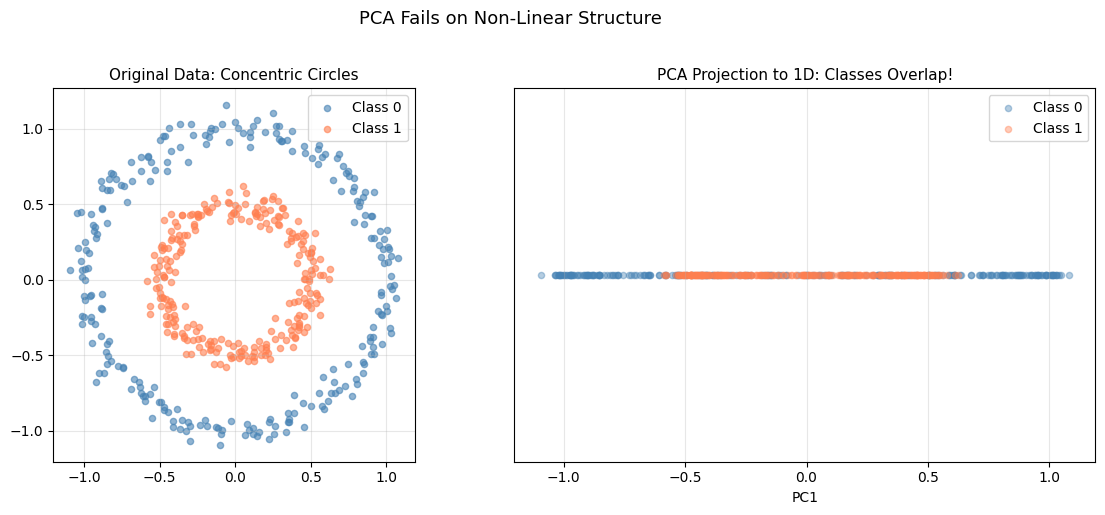

The two concentric circles are perfectly separable in 2D,
but PCA projection onto PC1 completely mixes the two classes.
Non-linear methods (kernel PCA, t-SNE, UMAP) handle this better.


In [ ]:
# Demonstrate PCA limitation: non-linear structure
np.random.seed(42)

# Create concentric circles (non-linear structure)
from sklearn.datasets import make_circles
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5)

# PCA on circles
pca_circles = PCA(n_components=2)
Z_circles = pca_circles.fit_transform(X_circles)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X_circles[y_circles==0, 0], X_circles[y_circles==0, 1],
           s=20, color='steelblue', alpha=0.6, label='Class 0')
ax1.scatter(X_circles[y_circles==1, 0], X_circles[y_circles==1, 1],
           s=20, color='coral', alpha=0.6, label='Class 1')
ax1.set_title('Original Data: Concentric Circles', fontsize=11)
ax1.set_aspect('equal'); ax1.legend(); ax1.grid(True, alpha=0.3)

# Project to 1D
Z_1d = pca_circles.transform(X_circles)[:, 0]
ax2.scatter(Z_1d[y_circles==0], np.zeros(sum(y_circles==0)),
           s=20, color='steelblue', alpha=0.4, label='Class 0')
ax2.scatter(Z_1d[y_circles==1], np.zeros(sum(y_circles==1)),
           s=20, color='coral', alpha=0.4, label='Class 1')
ax2.set_title('PCA Projection to 1D: Classes Overlap!', fontsize=11)
ax2.set_xlabel('PC1'); ax2.set_yticks([]); ax2.legend(); ax2.grid(True, alpha=0.3, axis='x')

fig.suptitle('PCA Fails on Non-Linear Structure', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The two concentric circles are perfectly separable in 2D,")
print("but PCA projection onto PC1 completely mixes the two classes.")
print("Non-linear methods (kernel PCA, t-SNE, UMAP) handle this better.")

The concentric circles example exposes PCA's fundamental limitation: it only captures **linear** correlations. The two classes are perfectly separable in the original 2D space (inner vs outer circle), but PCA's 1D projection completely mixes them because there is no linear direction that separates circles.

For data with non-linear structure, consider:
- **Kernel PCA** -- applies PCA in a higher-dimensional space via the kernel trick
- **t-SNE** -- optimizes for preserving local neighborhood structure (great for visualization)
- **UMAP** -- similar to t-SNE but faster and preserves more global structure
- **Autoencoders** -- neural networks that learn non-linear compressed representations

## 6.7 Key Takeaways

**Mechanism:** PCA uses **linear projection** to transform data into a lower-dimensional space. It finds the directions of **maximum variance** in the data and projects onto those directions.

**Solution:** The principal components are the right singular vectors of the centered data matrix (equivalently, eigenvectors of $\mathbf{X}^T\mathbf{X}$). The entire solution comes from the **SVD**: $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$.

**Mental model:** PCA squashes the data into a pancake that is **as fluffy as possible** in the retained directions. The singular values measure the "width" in each direction.

**Choosing $k$:** Use the scree plot (spectrum) or cumulative variance threshold (commonly 80% or 95%). Look for an "elbow" where adding more components gives diminishing returns.

**Whitening:** PCA naturally decorrelates features. Adding whitening ($\boldsymbol{\Sigma}^{-1}$ scaling) also normalizes their scales. ZCA whitens without reducing dimensionality.

**Limitations:** Only linear correlations; computationally expensive ($O(nd^2)$); uninterpretable components; sensitive to outliers in raw counts. Always transform count data (log, tf-idf) before applying PCA.

**Use cases:** Preprocessing for linear models, visualization, anomaly detection in time series, factor analysis in finance, image preprocessing (ZCA whitening).

---

*In Chapter 7, we explore nonlinear featurization via K-Means model stacking -- using clustering to create features that capture nonlinear structure that PCA misses.*